In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import PowerTransformer

# Загрузка данных

In [2]:
%%capture
!wget https://www.dropbox.com/s/64ol9q9ssggz6f1/data_ford_price.xlsx

In [3]:
data = pd.read_excel('data/ford_price.xlsx') 

# Трансформация признаков

У класса есть аргумент output_distribution, который отвечает за тип выходного распределения. Он может принимать значение ***'uniform'*** (равномерное распределение) или ***'normal'*** (нормальное распределение).

По умолчанию используется равномерное распределение, то есть значение параметра равно ***'uniform'***

Гиперпараметр ***n_quantiles*** определяет разрешение отображения или ранжирование наблюдений в наборе данных. Это значение должно быть меньше, чем количество наблюдений в наборе данных, и по умолчанию равно 1000.

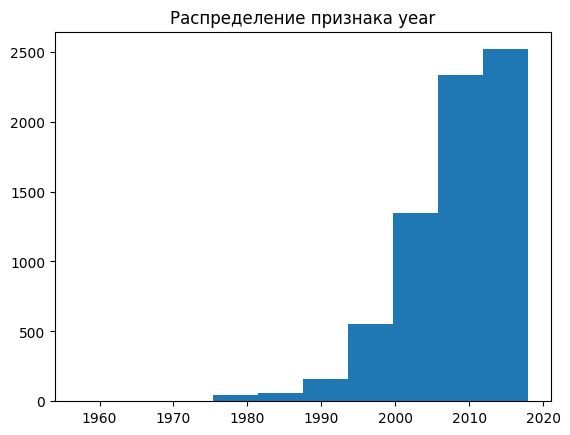

In [4]:
plt.hist(data.year)
plt.title('Распределение признака year');

## Квантильное преобразование

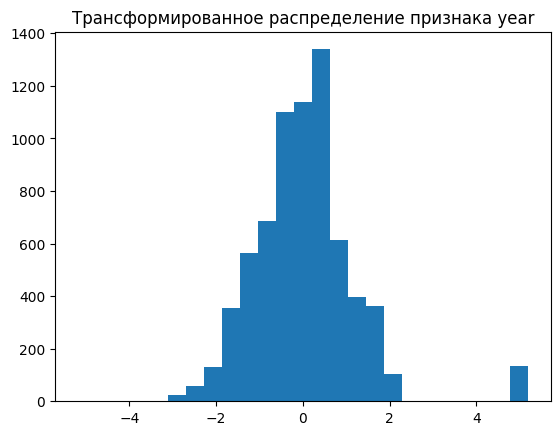

In [5]:
# Данный трансформер принимает на вход 2D-массив, поэтому нам надо изменить формат данных (поскольку мы подаём на вход только один столбец)
data_for_transform = data['year'].values.reshape((len(data),1))
 
quantile = QuantileTransformer(output_distribution='normal')
data_transformed = quantile.fit_transform(data_for_transform)
 
plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака year')
plt.show()

## Логарифмическое преобразование

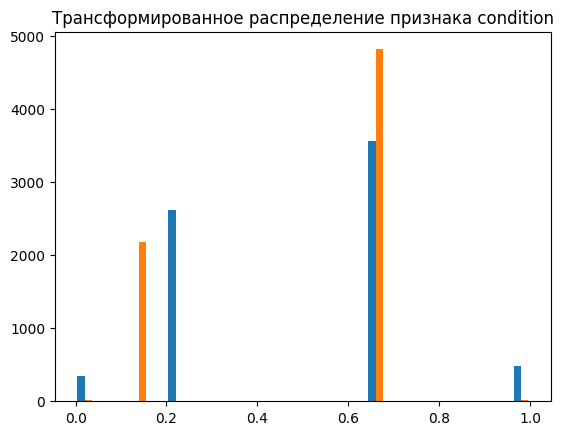

In [10]:
data_for_transform = data[['condition', 'cylinders']]
 
quantile = QuantileTransformer(output_distribution='uniform')
data_transformed = quantile.fit_transform(data_for_transform)
np.round(data_transformed[0][0], 2)

plt.hist(data_transformed, bins=25)
plt.title('Трансформированное распределение признака condition')
plt.show()

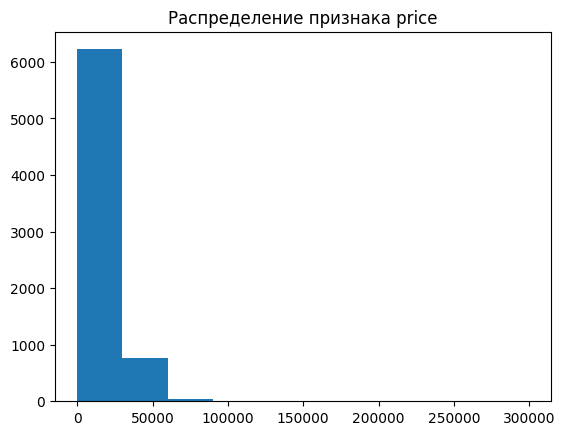

In [11]:
plt.hist(data.price)
plt.title('Распределение признака price');

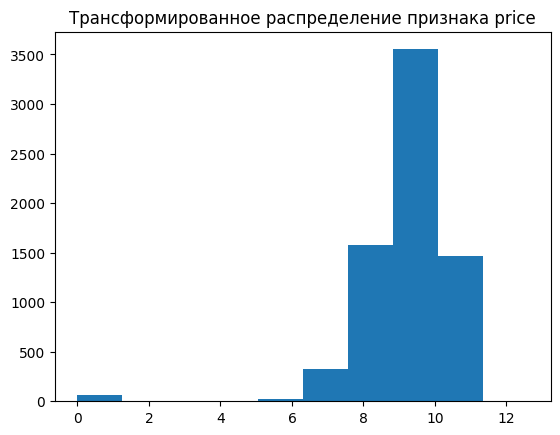

In [12]:
log_price = np.log(data['price'])
 
plt.hist(log_price)
plt.title('Трансформированное распределение признака price')
plt.show()

In [13]:
price_data = pd.concat([data['price'], log_price.rename('transformed_price')], axis = 1)
 
price_data.describe()

,price,transformed_price
count,7017.000000,7017.000000
mean,15121.549523,9.204510
std,11765.423119,1.275868
min,1.000000,0.000000
25%,5995.000000,8.698681
50%,12750.000000,9.453287
75%,21995.000000,9.998570
max,299500.000000,12.609870


In [15]:
price_data['transformed_price'].head()

0    10.689670
1     9.647950
2     7.822044
3     7.170120
4     9.537123
Name: transformed_price, dtype: float64

## Преобразование Бокса-Кокса

In [16]:
box_cox = PowerTransformer(method = 'box-cox')
 
data_box_cox = box_cox.fit_transform(data[['price', 'year']].values)
data_box_cox = pd.DataFrame(data_box_cox, columns = ['transformed_price', 'transformed_year'])

c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_morestats.py:1210: UserWarning: The optimal lambda is 123.77781881071438, but the returned lambda is the constrained optimum to ensure that the maximum or the minimum of the transformed data does not overflow in float64.
  lmax = boxcox_normmax(x, method='mle', optimizer=optimizer)
c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1230: RuntimeWarning: overflow encountered in square
  temp **= 2
c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: overflow encountered in square
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in subtract
  new_unnormalized_variance -= correction**2 / new_sample_count
c:\Users\Кирилл\AppData\Lo

c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\axes\_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
c:\Users\Кирилл\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\axes\_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

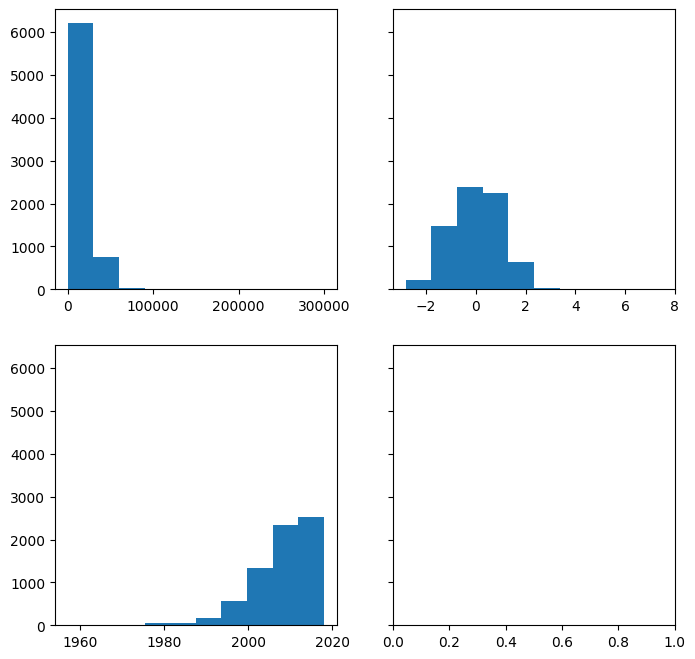

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharey=True)
axs[0][0].hist(data['price'])
axs[1][0].hist(data['year'])
axs[0][1].hist(data_box_cox['transformed_price'])
axs[1][1].hist(data_box_cox['transformed_year'])

axs[0][0].set(title='price')
axs[0][1].set(title='box cox price')

axs[1][0].set(title='year')
axs[1][1].set(title='box cox year')

fig.suptitle('Сравнение распределений до трансформации и после')

plt.show()